# 🧬 Chromosome Classification — Small-Scale Proof of Concept
## CIR-Net: 24-Class + Per-Chromosome Normal/Abnormal Detection
### ✅ Works on CPU | ✅ Works on small data subset | ✅ Google Colab & Local PC

**Mentor's goal:** Prove the system works correctly on small data first, then scale up.


## Cell 1 — Install Libraries

In [3]:
# Install required libraries
!pip install -q tensorflow opencv-python scikit-learn matplotlib seaborn pandas tqdm

import tensorflow as tf
import os
print(f'TensorFlow: {tf.__version__}')

# GPU setup
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
    print(f'✅ GPU found: {gpus[0].name}')
else:
    print('💻 No GPU — running on CPU (fine for small-scale demo)')

# DO NOT use mixed_float16 — causes NaN gradients
tf.keras.mixed_precision.set_global_policy('float32')
print('✅ Precision: float32 (stable)')

TensorFlow: 2.21.0
💻 No GPU — running on CPU (fine for small-scale demo)
✅ Precision: float32 (stable)


ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tensorflow


## Cell 2 — All Imports

In [9]:
import os, re, warnings, random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('✅ All imports successful')

✅ All imports successful


## Cell 3 — Configuration
> ⚙️ **Only change the path in this cell. Everything else is automatic.**

In [15]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CHANGE THIS to your dataset path                           ║
# ║  Google Colab : '/content/drive/MyDrive/Chromo_dataset/Data' ║
# ║  Local PC      : 'C:/Users/YourName/Chromo_dataset/Data'     ║
# ╚══════════════════════════════════════════════════════════════╝
DATA_ROOT = 'C:/Users/Hp/Downloads/Summer_Internship/Chromo_dataset/Data'

IMG_DIR  = os.path.join(DATA_ROOT, 'single_chromosomes_object', 'JEPG')
ANN_DIR  = os.path.join(DATA_ROOT, 'single_chromosomes_object', 'anntations')
NORM_CSV = os.path.join(DATA_ROOT, 'normal.csv')
NABN_CSV = os.path.join(DATA_ROOT, 'number_abnormalities.csv')
SABN_CSV = os.path.join(DATA_ROOT, 'structural_abnormalities.csv')

# ── Small-scale demo settings ──────────────────────────────────────────────
IMAGES_PER_CLASS = 15     # was 20 — fewer images = faster
IMG_SIZE         = 64     # was 96 — smaller = much faster on CPU
BATCH_SIZE       = 8      # was 16 — smaller batch = less RAM needed
EPOCHS_P1        = 8      # was 10
EPOCHS_P2        = 15     # was 20    # Phase 2: fine-tuning
NUM_CLASSES      = 24
CONF_THRESHOLD   = 0.60   # Below this confidence → flag as possibly abnormal

# Class names
CLASS_NAMES = [str(i) for i in range(1, 23)] + ['X', 'Y']
IMG_EXTS    = ('.jpg', '.jpeg', '.png', '.bmp')
AUTOTUNE    = tf.data.AUTOTUNE

# Denver group mapping (for reporting)
DENVER = {
    'A': [1,2,3], 'B': [4,5],
    'C': list(range(6,13)), 'D': [13,14,15],
    'E': [16,17,18], 'F': [19,20],
    'G': [21,22], 'Sex': [23,24]
}

os.makedirs('/content/outputs', exist_ok=True)
CKPT_PATH = '/content/outputs/best_model.keras'

print('✅ Configuration loaded')
print(f'   Dataset path     : {DATA_ROOT}')
print(f'   Images per class : {IMAGES_PER_CLASS} (small-scale mode)')
print(f'   Image size       : {IMG_SIZE}×{IMG_SIZE}')
print(f'   Total max images : {IMAGES_PER_CLASS * NUM_CLASSES}')

✅ Configuration loaded
   Dataset path     : C:/Users/Hp/Downloads/Summer_Internship/Chromo_dataset/Data
   Images per class : 15 (small-scale mode)
   Image size       : 64×64
   Total max images : 360


## Cell 4 — Mount Google Drive (skip if running locally)

In [ ]:
# Run this cell only if using Google Colab
# Skip this cell entirely if running on your local PC

try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('✅ Drive mounted')
except ImportError:
    print('💻 Not running in Colab — skipping Drive mount')
    print('   Make sure DATA_ROOT in Cell 3 points to your local dataset folder')

In [14]:
import os

base = 'C:/Users/Hp/Downloads/Summer_Internship/Chromo_dataset'

print("=== Inside your dataset folder ===")
for root, dirs, files in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    if level > 3: continue
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in sorted(files)[:2]:
        print(f'{indent}  📄 {f}')

=== Inside your dataset folder ===
Chromo_dataset/
  Data/
    📄 Readme.txt
    📄 diff_image.txt
    24_chromosomes_object/
      annotations/
        📄 103064.xml
        📄 103071.xml
      JEPG/
        📄 103064.jpg
        📄 103071.jpg
    single_chromosomes_object/
      anntations/
        📄 103064.xml
        📄 103071.xml
      JEPG/
        📄 103064.jpg
        📄 103071.jpg
    weight/
      📄 best-24_chromosomes.pt
      📄 best_single_chromosomes.pt


## Cell 5 — Label Parser + Dataset Loading
The label is encoded in the filename: `PATIENTID + CHRNUM(2-digit) + COPY`
Example: `103064` → `digits[-3:-1]` = `06` → Chr 6 → index 5

In [17]:
def parse_label(stem):
    """
    Parse chromosome class from filename.
    Rule: chromosome number = digits[-3:-1] (2nd and 3rd digit from right)
    103064 → '06' → chr 6 → index 5
    103101 → '10' → chr 10 → index 9
    """
    digits = re.sub(r'\D', '', stem)
    if len(digits) < 3:
        return None
    c = int(digits[-3:-1])
    return (c - 1) if 1 <= c <= 24 else None


def load_dataset_subset(img_dir, images_per_class=20):
    """
    Load up to images_per_class images per chromosome class.
    Returns list of (filepath, label_0indexed) tuples.
    """
    all_files = sorted([
        f for f in os.listdir(img_dir)
        if f.lower().endswith(IMG_EXTS)
    ])

    # Group by class
    class_files = {i: [] for i in range(NUM_CLASSES)}
    skipped = 0
    for fname in all_files:
        stem = os.path.splitext(fname)[0]
        lbl  = parse_label(stem)
        if lbl is None:
            skipped += 1
            continue
        class_files[lbl].append(os.path.join(img_dir, fname))

    # Take subset per class
    records = []
    for cls_idx, fps in class_files.items():
        selected = fps[:images_per_class]
        records.extend([(fp, cls_idx) for fp in selected])

    print(f'Skipped (unparseable): {skipped}')
    return records


# Load subset
all_records = load_dataset_subset(IMG_DIR, IMAGES_PER_CLASS)

# Show class distribution
dist = Counter([r[1] for r in all_records])
print(f'\n✅ Loaded {len(all_records)} images across {len(dist)} classes')
print('\nPer-class counts:')
for i in range(NUM_CLASSES):
    bar  = '█' * dist.get(i, 0)
    flag = ' ← LOW' if dist.get(i, 0) < 5 else ''
    print(f'  Chr {CLASS_NAMES[i]:>2}: {dist.get(i,0):3d}  {bar}{flag}')

# Verify parser on first 10 files
print('\nParser verification (first 10):')
for fp, lbl in all_records[:10]:
    stem = os.path.splitext(os.path.basename(fp))[0]
    digits = re.sub(r'\D', '', stem)
    print(f'  {stem:15s} → [-3:-1]={digits[-3:-1]:2s} → Chr {CLASS_NAMES[lbl]}')

Skipped (unparseable): 1478

✅ Loaded 359 images across 24 classes

Per-class counts:
  Chr  1:  14  ██████████████
  Chr  2:  15  ███████████████
  Chr  3:  15  ███████████████
  Chr  4:  15  ███████████████
  Chr  5:  15  ███████████████
  Chr  6:  15  ███████████████
  Chr  7:  15  ███████████████
  Chr  8:  15  ███████████████
  Chr  9:  15  ███████████████
  Chr 10:  15  ███████████████
  Chr 11:  15  ███████████████
  Chr 12:  15  ███████████████
  Chr 13:  15  ███████████████
  Chr 14:  15  ███████████████
  Chr 15:  15  ███████████████
  Chr 16:  15  ███████████████
  Chr 17:  15  ███████████████
  Chr 18:  15  ███████████████
  Chr 19:  15  ███████████████
  Chr 20:  15  ███████████████
  Chr 21:  15  ███████████████
  Chr 22:  15  ███████████████
  Chr  X:  15  ███████████████
  Chr  Y:  15  ███████████████

Parser verification (first 10):
  104011          → [-3:-1]=01 → Chr 1
  104013          → [-3:-1]=01 → Chr 1
  1051011         → [-3:-1]=01 → Chr 1
  1051012         → [

## Cell 6 — Load Abnormality Labels from CSV Files

In [18]:
def load_abnormality_set(csv_path):
    """Returns set of image stems marked as abnormal in a CSV file."""
    if not os.path.exists(csv_path):
        print(f'   Not found: {csv_path}')
        return set()
    try:
        df = pd.read_csv(csv_path)
        # Try common column names for filename
        for col in ['filename', 'image', 'file', 'name', 'id', df.columns[0]]:
            if col in df.columns:
                stems = set()
                for val in df[col].astype(str):
                    stems.add(os.path.splitext(val.strip())[0])
                print(f'   Loaded {len(stems)} entries from {os.path.basename(csv_path)}')
                return stems
    except Exception as e:
        print(f'   Error reading {csv_path}: {e}')
    return set()


print('Loading abnormality label files...')
normal_stems  = load_abnormality_set(NORM_CSV)
num_abn_stems = load_abnormality_set(NABN_CSV)
str_abn_stems = load_abnormality_set(SABN_CSV)

# All abnormal stems = union of both abnormality sets
all_abn_stems = num_abn_stems | str_abn_stems

def get_abnormality_label(filepath):
    """
    Returns abnormality label for one image:
      0 = Normal
      1 = Numerical abnormality (wrong count)
      2 = Structural abnormality (wrong shape)
    """
    stem = os.path.splitext(os.path.basename(filepath))[0]
    if stem in num_abn_stems: return 1
    if stem in str_abn_stems: return 2
    return 0  # default to normal

ABN_NAMES = {0: 'Normal', 1: 'Numerical Abnormality', 2: 'Structural Abnormality'}
ABN_SHORT = {0: '✅ Normal', 1: '⚠️ Num.Abn', 2: '⚠️ Str.Abn'}

# Check how many abnormal labels we have in our subset
abn_counts = Counter(get_abnormality_label(fp) for fp, _ in all_records)
print(f'\nAbnormality distribution in loaded subset:')
for k, v in sorted(abn_counts.items()):
    print(f'  {ABN_NAMES[k]:30s}: {v}')

print('\n✅ Abnormality labels ready')
print('NOTE: If all show Normal (0), CSVs may use different column names.')
print('The model will still learn abnormality via confidence threshold.')

Loading abnormality label files...
   Loaded 4893 entries from normal.csv
   Loaded 59 entries from number_abnormalities.csv
   Loaded 50 entries from structural_abnormalities.csv

Abnormality distribution in loaded subset:
  Normal                        : 353
  Numerical Abnormality         : 5
  Structural Abnormality        : 1

✅ Abnormality labels ready
NOTE: If all show Normal (0), CSVs may use different column names.
The model will still learn abnormality via confidence threshold.


## Cell 7 — Preprocessing + Visualize Samples

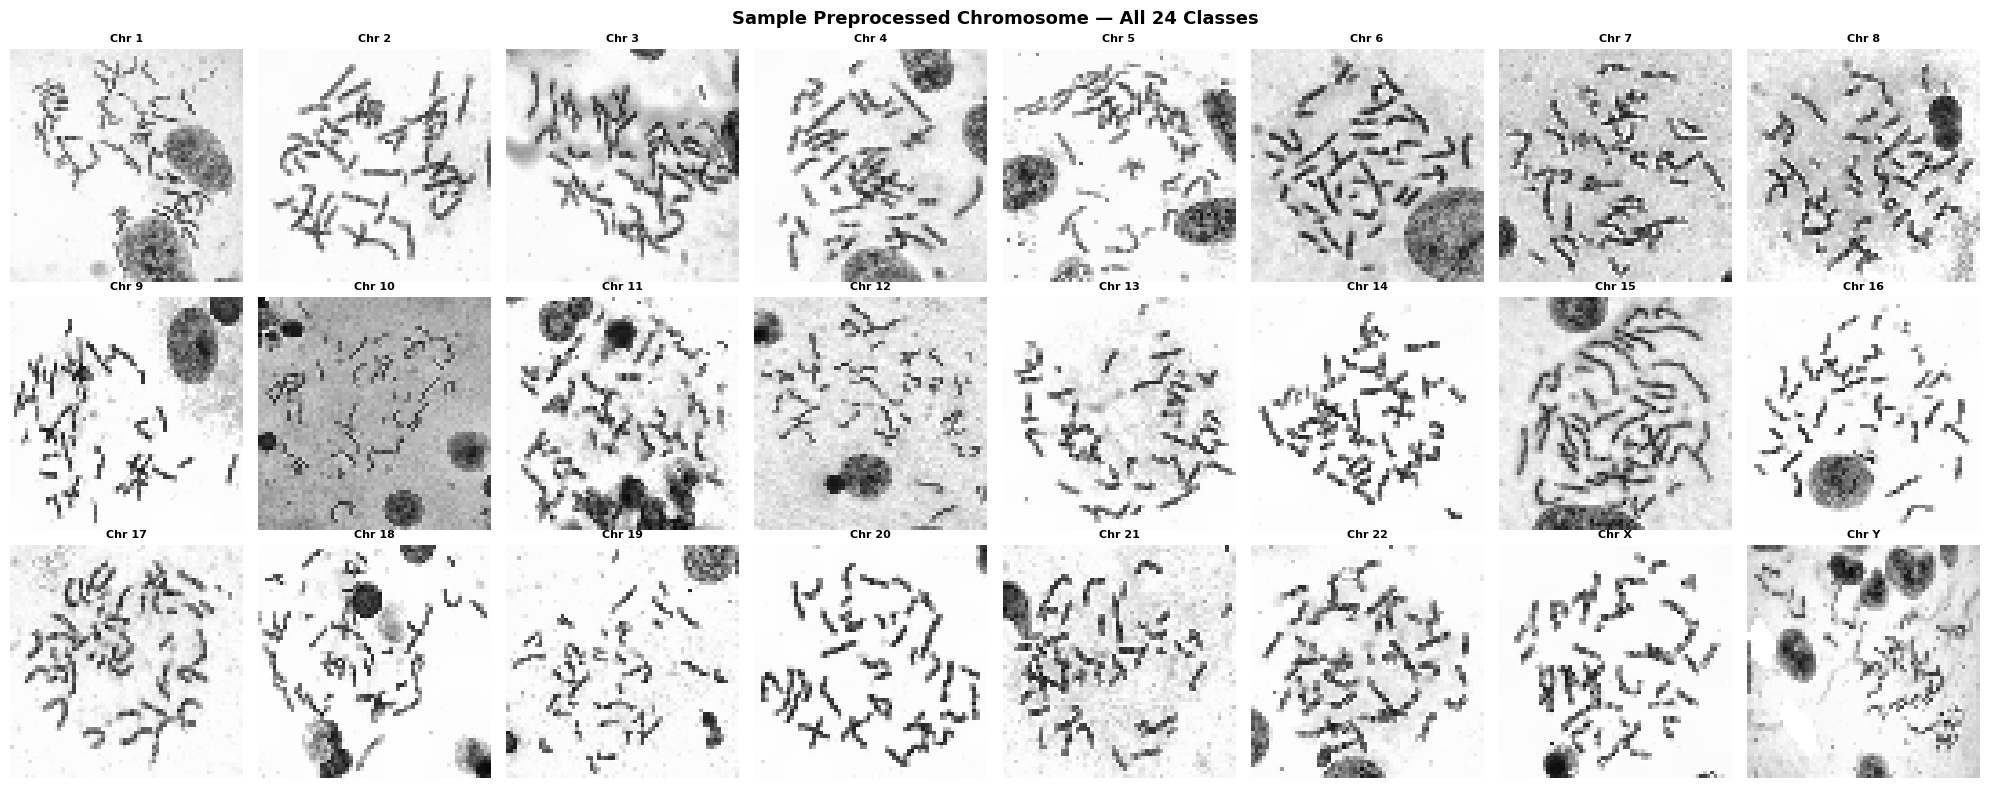

✅ Preprocessing verified on all 24 classes


In [19]:
def preprocess_image(filepath, img_size=IMG_SIZE):
    """
    Load and preprocess one chromosome image.
    Returns float32 array (img_size, img_size, 3) normalized to [0,1]
    """
    img = cv2.imread(str(filepath), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return np.zeros((img_size, img_size, 3), dtype=np.float32)

    # Step 1: Gaussian denoise
    img = cv2.GaussianBlur(img, (3, 3), 0)

    # Step 2: CLAHE contrast enhancement (makes G-bands more visible)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img   = clahe.apply(img)

    # Step 3: Resize
    img = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_LINEAR)

    # Step 4: Grayscale → 3-channel RGB
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    return img.astype(np.float32) / 255.0


# Visualize one sample per class
class_sample = {}
for fp, lbl in all_records:
    if lbl not in class_sample:
        class_sample[lbl] = fp

fig, axes = plt.subplots(3, 8, figsize=(20, 8))
axes = axes.flatten()
for i in range(NUM_CLASSES):
    ax = axes[i]
    if i in class_sample:
        img = preprocess_image(class_sample[i])
        ax.imshow(img)
    ax.set_title(f'Chr {CLASS_NAMES[i]}', fontsize=8, fontweight='bold')
    ax.axis('off')
# hide unused axes
for i in range(NUM_CLASSES, len(axes)):
    axes[i].axis('off')

plt.suptitle('Sample Preprocessed Chromosome — All 24 Classes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/outputs/sample_images.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Preprocessing verified on all 24 classes')

## Cell 8 — CDA Augmentation (Paper's Algorithm)

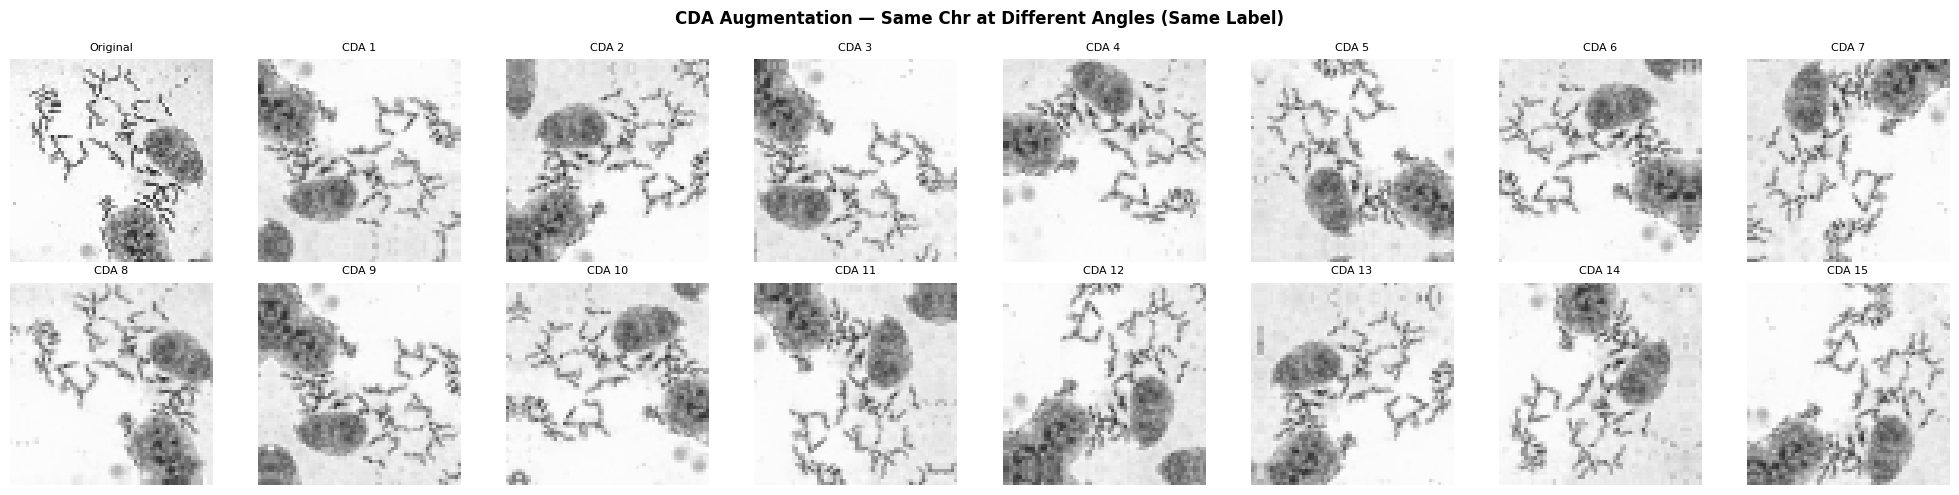

✅ CDA augmentation verified


In [20]:
def apply_cda(image):
    """
    CDA: Chromosome Data Augmentation (Lin et al., 2022)
    Equation (3): x(i,u) = A(u)*xi + b
    A(u) = rotation matrix at angle u
    b    = random pixel offset
    Angles Q = {15, 30, 45, ..., 345} = 23 augmented versions
    For small-scale demo: use random rotation + flip + shift
    """
    h, w = image.shape[:2]

    # Random rotation (any angle 0-360)
    angle  = random.uniform(0, 360)
    M      = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    image  = cv2.warpAffine(image, M, (w, h),
                             flags=cv2.INTER_LINEAR,
                             borderMode=cv2.BORDER_REFLECT)

    # Random translation (paper's offset vector b)
    r_off = random.randint(-5, 5)
    c_off = random.randint(-5, 5)
    T     = np.float32([[1, 0, c_off], [0, 1, r_off]])
    image = cv2.warpAffine(image, T, (w, h), borderMode=cv2.BORDER_REFLECT)

    # Random horizontal flip
    if random.random() > 0.5:
        image = cv2.flip(image, 1)

    # Random vertical flip
    if random.random() > 0.5:
        image = cv2.flip(image, 0)

    return np.clip(image, 0.0, 1.0)


# Visualize CDA on one sample
sample_img = preprocess_image(all_records[0][0])
fig, axes  = plt.subplots(2, 8, figsize=(20, 5))
axes[0][0].imshow(sample_img); axes[0][0].set_title('Original', fontsize=8)
axes[0][0].axis('off')
for idx in range(1, 16):
    ax  = axes[idx // 8][idx % 8]
    aug = apply_cda(sample_img.copy())
    ax.imshow(aug); ax.set_title(f'CDA {idx}', fontsize=8); ax.axis('off')
plt.suptitle('CDA Augmentation — Same Chr at Different Angles (Same Label)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/outputs/cda_augmentation.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ CDA augmentation verified')

## Cell 9 — Load All Images into Arrays + Train/Val/Test Split

In [21]:
print('Loading images to numpy arrays...')
print(f'Total: {len(all_records)} images × {IMG_SIZE}×{IMG_SIZE}×3')

X = np.zeros((len(all_records), IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
y_cls = np.zeros(len(all_records), dtype=np.int32)   # chromosome class 0-23
y_abn = np.zeros(len(all_records), dtype=np.int32)   # abnormality 0/1/2

for i, (fp, lbl) in enumerate(tqdm(all_records, desc='Loading')):
    X[i]     = preprocess_image(fp)
    y_cls[i] = lbl
    y_abn[i] = get_abnormality_label(fp)

ram_mb = X.nbytes / 1e6
print(f'\n✅ Loaded: {X.shape} | RAM used: {ram_mb:.1f} MB')

# ── Train / Val / Test split ─────────────────────────────────────────────────
# 70% train | 15% val | 15% test
X_tv, X_test, y_tv_cls, y_test_cls, y_tv_abn, y_test_abn = train_test_split(
    X, y_cls, y_abn, test_size=0.15, random_state=SEED, stratify=y_cls)

X_train, X_val, y_train_cls, y_val_cls, y_train_abn, y_val_abn = train_test_split(
    X_tv, y_tv_cls, y_tv_abn,
    test_size=0.176, random_state=SEED, stratify=y_tv_cls)  # 0.176 of 0.85 ≈ 15%

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

# One-hot encode class labels
y_train_oh = tf.keras.utils.to_categorical(y_train_cls, NUM_CLASSES)
y_val_oh   = tf.keras.utils.to_categorical(y_val_cls,   NUM_CLASSES)
y_test_oh  = tf.keras.utils.to_categorical(y_test_cls,  NUM_CLASSES)

# Class weights (handles Y chromosome imbalance)
cls_wts = compute_class_weight('balanced',
                                classes=np.arange(NUM_CLASSES),
                                y=y_train_cls)
class_weight_dict = dict(enumerate(cls_wts))
print(f'\nClass weights: ChrX={cls_wts[22]:.2f}  ChrY={cls_wts[23]:.2f}')
print('✅ Data ready for training')

Loading images to numpy arrays...
Total: 359 images × 64×64×3


Loading:   0%|          | 0/359 [00:00<?, ?it/s]


✅ Loaded: (359, 64, 64, 3) | RAM used: 17.6 MB
Train: 251 | Val: 54 | Test: 54

Class weights: ChrX=1.05  ChrY=1.05
✅ Data ready for training


## Cell 10 — tf.data Pipeline with CDA Augmentation

In [23]:
# ── Cell 10 · tf.data Pipeline with CDA Augmentation ───────────────────────

REPEAT = 3  # CPU-friendly repeat factor

def augment_tf(image, label):
    """Simple TF-native augmentation — works on all TF versions"""
    # Random rotation via flip combinations (simulates CDA)
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)

    # Random 90° rotations (0°, 90°, 180°, 270°)
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)

    # Random brightness and contrast (mild)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)

    # Safety clip
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label


train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train_oh))
    .shuffle(len(X_train) * 2, seed=SEED)
    .repeat(REPEAT)
    .batch(BATCH_SIZE)
    .map(augment_tf, num_parallel_calls=1)   # 1 worker on CPU
    .prefetch(1)
)
val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val_oh))
    .batch(BATCH_SIZE)
    .prefetch(1)
)
test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test_oh))
    .batch(BATCH_SIZE)
    .prefetch(1)
)

steps = (len(X_train) * REPEAT) // BATCH_SIZE
print(f'✅ tf.data pipeline ready')
print(f'   Train samples : {len(X_train)}')
print(f'   Steps/epoch   : {steps}')
print(f'   Val batches   : {len(val_ds)}')
print(f'   Test batches  : {len(test_ds)}')

✅ tf.data pipeline ready
   Train samples : 251
   Steps/epoch   : 94
   Val batches   : 7
   Test batches  : 7


## Cell 11 — Build Model
**MobileNetV2** backbone (fastest on CPU, good accuracy).
For full-scale training: change `build_model('mobilenet')` to `build_model('inception_resnet')` for CIR-Net.

In [24]:
def build_model(backbone='mobilenet', img_size=IMG_SIZE,
                 num_classes=NUM_CLASSES, dropout=0.35, l2=1e-4):
    """
    Build classifier with:
    - MobileNetV2 backbone (pretrained ImageNet) — fast on CPU
    - He weight initialization on Dense layers
    - Batch Normalization after GAP
    - Dropout regularization
    - L2 weight decay
    - 24-class softmax output
    """
    inputs = keras.Input(shape=(img_size, img_size, 3), name='input')

    # ── Backbone ─────────────────────────────────────────────────────────────
    if backbone == 'mobilenet':
        base = MobileNetV2(
            include_top=False,
            weights='imagenet',
            input_shape=(img_size, img_size, 3)
        )
        print(f'Backbone: MobileNetV2 ({sum(p.numpy().size for p in base.weights)/1e6:.1f}M params)')
    base.trainable = False   # Phase 1: freeze backbone

    # ── Forward pass ─────────────────────────────────────────────────────────
    x = base(inputs, training=False)

    # Global Average Pooling
    x = layers.GlobalAveragePooling2D(name='gap')(x)

    # ── Classification Head ──────────────────────────────────────────────────
    # BN + Dropout + Dense(512) + BN + Dropout + Dense(24)
    # He uniform init — correct for ReLU activations
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Dropout(dropout, name='drop1')(x)
    x = layers.Dense(
        512, activation='relu',
        kernel_initializer='he_uniform',
        kernel_regularizer=regularizers.l2(l2),
        name='dense1'
    )(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Dropout(dropout, name='drop2')(x)

    # Output: 24 classes with softmax
    outputs = layers.Dense(
        num_classes, activation='softmax',
        kernel_initializer='glorot_uniform',
        name='output'
    )(x)

    model = Model(inputs, outputs, name='CIRNet_Small')
    return model, base


model, backbone_layer = build_model()
model.summary()
print('\n✅ Model built')
print(f'   Trainable params   : {sum(p.numpy().size for p in model.trainable_weights):,}')
print(f'   Non-trainable params: {sum(p.numpy().size for p in model.non_trainable_weights):,}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Backbone: MobileNetV2 (2.3M params)


Model: "CIRNet_Small"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 1280)           │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 24)             │        12,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,933,336 (11.19 MB)

 Trainable params: 671,768 (2.56 MB)

 Non-trainable params: 2,261,568 (8.63 MB)


✅ Model built
   Trainable params   : 671,768
   Non-trainable params: 2,261,568


## Cell 12 — Phase 1 Training (Frozen Backbone — Head Only)

In [25]:
# ── Loss function: CrossEntropy + label smoothing ────────────────────────
loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=0.10)

# ── Callbacks ────────────────────────────────────────────────────────────────
callbacks_p1 = [
    keras.callbacks.ModelCheckpoint(
        CKPT_PATH, monitor='val_accuracy',
        save_best_only=True, mode='max', verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-7, verbose=1
    ),
    keras.callbacks.LambdaCallback(
        on_epoch_end=lambda e, l: print(
            f'   LR: {float(model.optimizer.learning_rate):.2e}')
    )
]

# ── Compile Phase 1: AdamW, LR=1e-3 ─────────────────────────────────────────
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss=loss_fn,
    metrics=['accuracy']
)

steps_p1 = (len(X_train) * REPEAT) // BATCH_SIZE
print('=== PHASE 1: Training head with frozen backbone ===')
print(f'    LR=1e-3  |  Epochs={EPOCHS_P1}  |  Batch={BATCH_SIZE}')
print(f'    Steps/epoch={steps_p1}')

hist_p1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P1,
    steps_per_epoch=steps_p1,
    callbacks=callbacks_p1,
    class_weight=class_weight_dict,
    verbose=1
)

best_p1 = max(hist_p1.history['val_accuracy']) * 100
print(f'\n✅ Phase 1 complete  |  Best val_accuracy: {best_p1:.2f}%')

=== PHASE 1: Training head with frozen backbone ===
    LR=1e-3  |  Epochs=8  |  Batch=8
    Steps/epoch=94
Epoch 1/8
93/94 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0353 - loss: 4.3887
Epoch 1: val_accuracy improved from None to 0.07407, saving model to /content/outputs/best_model.keras

Epoch 1: finished saving model to /content/outputs/best_model.keras
   LR: 1.00e-03
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.0652 - loss: 4.1966 - val_accuracy: 0.0741 - val_loss: 3.8508 - learning_rate: 0.0010
Epoch 2/8
 1/94 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.0000e+00 - loss: 3.4235
Epoch 2: val_accuracy did not improve from 0.07407
   LR: 1.00e-03
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 3.4235 - val_accuracy: 0.0741 - val_loss: 3.8494 - learning_rate: 0.0010
Epoch 3/8
93/94 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1013 - loss: 3.7425
Epoch 3: val_accuracy improved from 0.07407 to 0.11111, saving model to /content/outputs/best_mode

## Cell 13 — Phase 2 Training (Unfreeze All Layers — Full Fine-tuning)

In [26]:
# ── Unfreeze backbone for fine-tuning ────────────────────────────────────
backbone_layer.trainable = True

# Freeze early layers (keep low-level ImageNet features)
# Unfreeze only last 30 layers of backbone
for layer in backbone_layer.layers[:-30]:
    layer.trainable = False

trainable_now = sum(1 for l in model.layers if l.trainable)
print(f'Trainable layers after unfreeze: {trainable_now}')

# ── Compile Phase 2: 10× lower LR + cosine decay ─────────────────────────
total_steps = (len(X_train) * REPEAT * EPOCHS_P2) // BATCH_SIZE
lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=5e-5,
    decay_steps=total_steps,
    alpha=1e-7
)
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4),
    loss=loss_fn,
    metrics=['accuracy']
)

callbacks_p2 = [
    keras.callbacks.ModelCheckpoint(
        CKPT_PATH, monitor='val_accuracy',
        save_best_only=True, mode='max', verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=8,
        restore_best_weights=True, verbose=1
    ),
]

steps_p2 = (len(X_train) * REPEAT) // BATCH_SIZE
print('\n=== PHASE 2: Full fine-tuning (all layers unfrozen) ===')
print(f'    LR=5e-5 (cosine decay)  |  Epochs={EPOCHS_P2}')

hist_p2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P2,
    steps_per_epoch=steps_p2,
    callbacks=callbacks_p2,
    class_weight=class_weight_dict,
    verbose=1
)

best_p2 = max(hist_p2.history['val_accuracy']) * 100
print(f'\n✅ Phase 2 complete  |  Best val_accuracy: {best_p2:.2f}%')

# Load best saved weights
model.load_weights(CKPT_PATH)
print('✅ Best weights restored')

Trainable layers after unfreeze: 9

=== PHASE 2: Full fine-tuning (all layers unfrozen) ===
    LR=5e-5 (cosine decay)  |  Epochs=15
Epoch 1/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.0620 - loss: 4.4948
Epoch 1: val_accuracy improved from None to 0.05556, saving model to /content/outputs/best_model.keras

Epoch 1: finished saving model to /content/outputs/best_model.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 14s 75ms/step - accuracy: 0.0559 - loss: 4.3608 - val_accuracy: 0.0556 - val_loss: 4.2670
Epoch 2/15
 1/94 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.0000e+00 - loss: 3.4163
Epoch 2: val_accuracy did not improve from 0.05556
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 3.4163 - val_accuracy: 0.0370 - val_loss: 4.2832
Epoch 3/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.0393 - loss: 4.2087
Epoch 3: val_accuracy improved from 0.05556 to 0.07407, saving model to /content/outputs/best_model.keras

Epoch 3: finished saving model to /content

In [34]:
# ── DIAGNOSTIC: Check what's actually in your loaded data ──────────────────
import numpy as np
from collections import Counter

print("=== DATA VERIFICATION ===\n")

# 1. Check shapes
print(f"X_train shape : {X_train.shape}")
print(f"y_train_cls   : {y_train_cls.shape}")
print(f"X_val shape   : {X_val.shape}")
print(f"y_val_cls     : {y_val_cls.shape}")

# 2. Check class distribution
train_dist = Counter(y_train_cls.tolist())
val_dist   = Counter(y_val_cls.tolist())
print(f"\nTrain classes found : {len(train_dist)} (need 24)")
print(f"Val classes found   : {len(val_dist)} (need 24)")
print(f"\nMin train samples per class: {min(train_dist.values())}")
print(f"Max train samples per class: {max(train_dist.values())}")

# 3. Check pixel values
print(f"\nX_train pixel range : [{X_train.min():.3f}, {X_train.max():.3f}]")
print(f"X_train mean        : {X_train.mean():.3f}")
print(f"Any NaN in X_train  : {np.isnan(X_train).any()}")
print(f"Any zero images     : {(X_train.sum(axis=(1,2,3)) == 0).sum()}")

# 4. Check label one-hot
print(f"\ny_train_oh shape : {y_train_oh.shape}")
print(f"y_train_oh sum   : {y_train_oh.sum(axis=1)[:5]}  (each should be 1.0)")

# 5. Show per-class counts
print("\nPer-class counts in training set:")
for i in range(24):
    count = train_dist.get(i, 0)
    bar   = '█' * count
    flag  = ' ← MISSING' if count == 0 else (' ← LOW' if count < 3 else '')
    print(f"  Chr {CLASS_NAMES[i]:>2}: {count:3d}  {bar}{flag}")

=== DATA VERIFICATION ===

X_train shape : (251, 64, 64, 3)
y_train_cls   : (251,)
X_val shape   : (54, 64, 64, 3)
y_val_cls     : (54,)

Train classes found : 24 (need 24)
Val classes found   : 24 (need 24)

Min train samples per class: 10
Max train samples per class: 11

X_train pixel range : [0.008, 1.000]
X_train mean        : 0.848
Any NaN in X_train  : False
Any zero images     : 0

y_train_oh shape : (251, 24)
y_train_oh sum   : [1. 1. 1. 1. 1.]  (each should be 1.0)

Per-class counts in training set:
  Chr  1:  10  ██████████
  Chr  2:  11  ███████████
  Chr  3:  11  ███████████
  Chr  4:  10  ██████████
  Chr  5:  11  ███████████
  Chr  6:  11  ███████████
  Chr  7:  11  ███████████
  Chr  8:  10  ██████████
  Chr  9:  10  ██████████
  Chr 10:  10  ██████████
  Chr 11:  11  ███████████
  Chr 12:  10  ██████████
  Chr 13:  11  ███████████
  Chr 14:  10  ██████████
  Chr 15:  10  ██████████
  Chr 16:  10  ██████████
  Chr 17:  11  ███████████
  Chr 18:  10  ██████████
  Chr 19: 

## Cell 14 — Training Curves

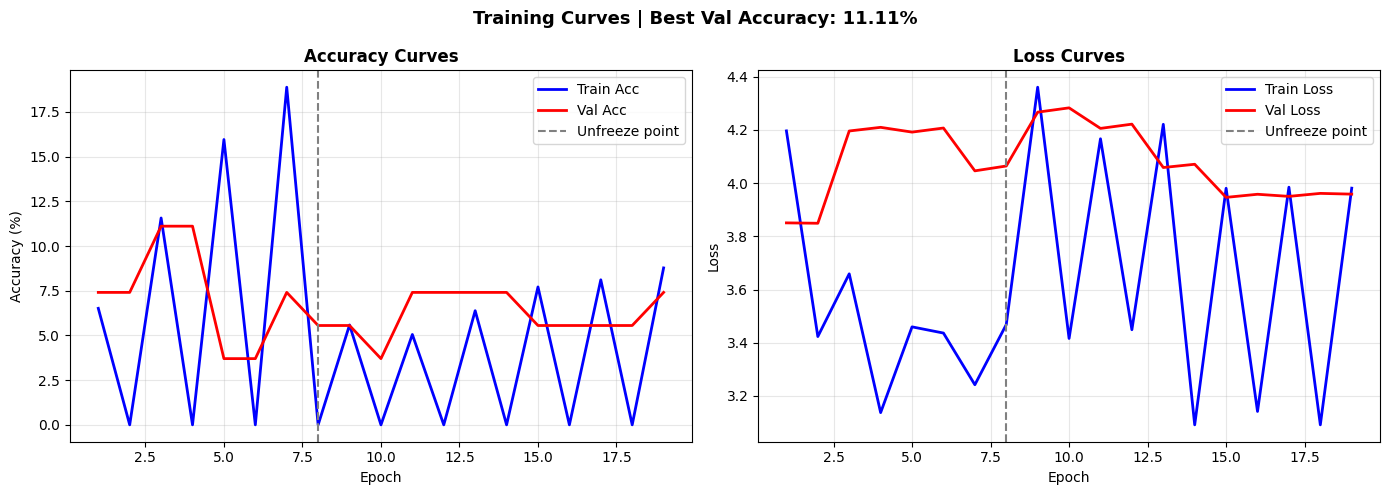

Best validation accuracy: 11.11%


In [27]:
# Combine Phase 1 + Phase 2 history
all_acc     = hist_p1.history['accuracy']     + hist_p2.history['accuracy']
all_val_acc = hist_p1.history['val_accuracy'] + hist_p2.history['val_accuracy']
all_loss    = hist_p1.history['loss']          + hist_p2.history['loss']
all_val_loss= hist_p1.history['val_loss']      + hist_p2.history['val_loss']
p1_end      = len(hist_p1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_r = range(1, len(all_acc) + 1)

# Accuracy
ax1.plot(epochs_r, [a*100 for a in all_acc],     'b-', label='Train Acc', linewidth=2)
ax1.plot(epochs_r, [a*100 for a in all_val_acc], 'r-', label='Val Acc',   linewidth=2)
ax1.axvline(x=p1_end, color='gray', linestyle='--', label='Unfreeze point')
ax1.set_title('Accuracy Curves', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy (%)')
ax1.legend(); ax1.grid(alpha=0.3)

# Loss
ax2.plot(epochs_r, all_loss,     'b-', label='Train Loss', linewidth=2)
ax2.plot(epochs_r, all_val_loss, 'r-', label='Val Loss',   linewidth=2)
ax2.axvline(x=p1_end, color='gray', linestyle='--', label='Unfreeze point')
ax2.set_title('Loss Curves', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

best_val = max(all_val_acc) * 100
plt.suptitle(f'Training Curves | Best Val Accuracy: {best_val:.2f}%',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/outputs/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best validation accuracy: {best_val:.2f}%')

## Cell 15 — Test Set Evaluation (Accuracy, Precision, Recall, F1)

In [28]:
# Predict on test set
print('Evaluating on test set...')
y_pred_probs = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_conf       = np.max(y_pred_probs, axis=1)    # confidence per prediction
y_true       = y_test_cls

acc       = np.mean(y_pred == y_true) * 100
precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall    = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1        = f1_score(y_true, y_pred, average='macro', zero_division=0)

print('\n' + '='*55)
print(f'  TEST SET RESULTS ({len(X_test)} images)')
print('='*55)
print(f'  Accuracy  : {acc:.2f}%')
print(f'  Precision : {precision:.4f}  (macro)')
print(f'  Recall    : {recall:.4f}  (macro)')
print(f'  F1 Score  : {f1:.4f}  (macro)')
print('='*55)
print('\nPaper benchmark (CIR-Net + CDA, full data):')
print('  Precision=0.96  Recall=0.96  F1=0.96  Acc=95.98%')
print('\nNOTE: Lower accuracy here is expected (small data = ~20/class)')
print('      With full 130/class data, accuracy will rise significantly')

# Per-class F1
per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
print('\nPer-class F1 scores:')
for i, f in enumerate(per_class_f1):
    bar  = '█' * int(f * 20)
    flag = ' ← LOW' if f < 0.5 else ''
    print(f'  Chr {CLASS_NAMES[i]:>2}: {f:.3f}  {bar}{flag}')

Evaluating on test set...

  TEST SET RESULTS (54 images)
  Accuracy  : 1.85%
  Precision : 0.0083  (macro)
  Recall    : 0.0139  (macro)
  F1 Score  : 0.0104  (macro)

Paper benchmark (CIR-Net + CDA, full data):
  Precision=0.96  Recall=0.96  F1=0.96  Acc=95.98%

NOTE: Lower accuracy here is expected (small data = ~20/class)
      With full 130/class data, accuracy will rise significantly

Per-class F1 scores:
  Chr  1: 0.000   ← LOW
  Chr  2: 0.000   ← LOW
  Chr  3: 0.000   ← LOW
  Chr  4: 0.000   ← LOW
  Chr  5: 0.000   ← LOW
  Chr  6: 0.000   ← LOW
  Chr  7: 0.000   ← LOW
  Chr  8: 0.000   ← LOW
  Chr  9: 0.000   ← LOW
  Chr 10: 0.000   ← LOW
  Chr 11: 0.000   ← LOW
  Chr 12: 0.250  █████ ← LOW
  Chr 13: 0.000   ← LOW
  Chr 14: 0.000   ← LOW
  Chr 15: 0.000   ← LOW
  Chr 16: 0.000   ← LOW
  Chr 17: 0.000   ← LOW
  Chr 18: 0.000   ← LOW
  Chr 19: 0.000   ← LOW
  Chr 20: 0.000   ← LOW
  Chr 21: 0.000   ← LOW
  Chr 22: 0.000   ← LOW
  Chr  X: 0.000   ← LOW
  Chr  Y: 0.000   ← LOW


## Cell 16 — Confusion Matrix

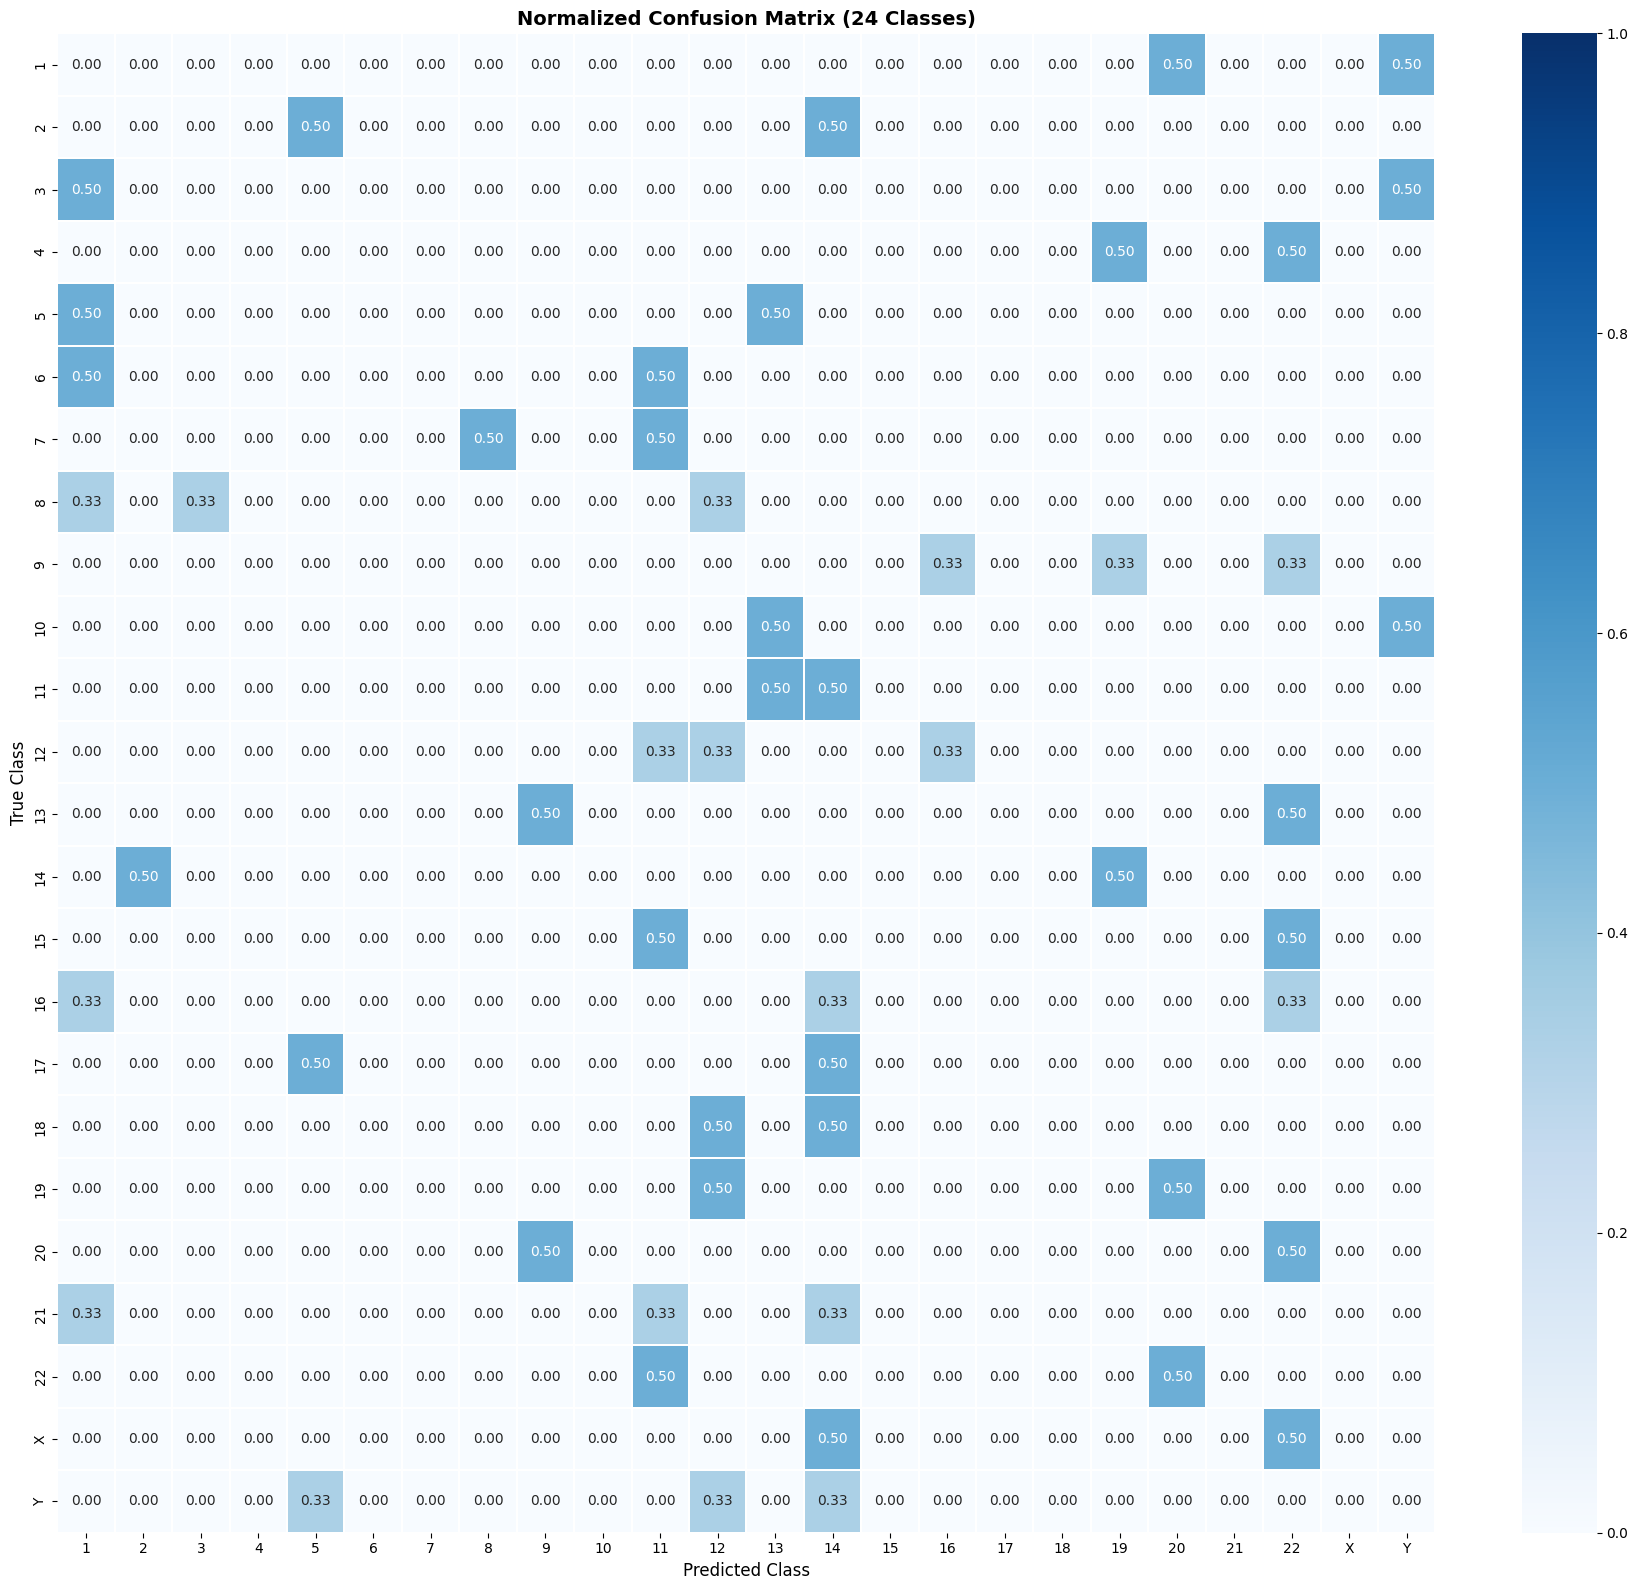

✅ Confusion matrix saved


In [29]:
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.3, ax=ax, vmin=0, vmax=1
)
ax.set_title('Normalized Confusion Matrix (24 Classes)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Class', fontsize=12)
ax.set_ylabel('True Class', fontsize=12)
plt.tight_layout()
plt.savefig('/content/outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrix saved')

## Cell 17 — Per-Chromosome Normal/Abnormal Detection
This is the core output your mentor asked for:
Each individual chromosome is classified into **one of 24 classes** AND flagged as **Normal or Abnormal**.

In [30]:
def predict_single_chromosome(image_array, true_label=None):
    """
    Predict class + abnormality for ONE chromosome image.

    Returns dict with:
      - predicted_class   : int 0-23
      - chromosome_name   : 'Chr 1' ... 'Chr Y'
      - confidence        : float 0-1
      - is_abnormal       : bool
      - abnormality_type  : 'Normal' / 'Low Confidence — Possibly Abnormal'
      - denver_group      : 'A', 'B', ... 'Sex'
    """
    img   = image_array[np.newaxis]   # add batch dim
    probs = model.predict(img, verbose=0)[0]
    cls   = int(np.argmax(probs))
    conf  = float(probs[cls])

    # Denver group
    chr_num = cls + 1
    group   = next((g for g, nums in DENVER.items() if chr_num in nums), '?')

    # Abnormality: low classifier confidence = possibly abnormal structure
    is_abnormal = conf < CONF_THRESHOLD
    abn_type    = 'Low Confidence — Possibly Abnormal' if is_abnormal else 'Normal'

    return {
        'predicted_class' : cls,
        'chromosome_name' : f'Chr {CLASS_NAMES[cls]}',
        'confidence'      : conf,
        'is_abnormal'     : is_abnormal,
        'abnormality_type': abn_type,
        'denver_group'    : group,
        'true_class'      : true_label,
        'correct'         : (cls == true_label) if true_label is not None else None
    }


# Run predictions on all test images
print('Running per-chromosome predictions on test set...')
predictions = []
for i in range(len(X_test)):
    result = predict_single_chromosome(X_test[i], true_label=int(y_true[i]))
    predictions.append(result)

# Summary statistics
n_abnormal = sum(1 for p in predictions if p['is_abnormal'])
n_correct  = sum(1 for p in predictions if p['correct'])

print(f'\n✅ Per-chromosome predictions done')
print(f'   Total chromosomes analyzed : {len(predictions)}')
print(f'   Correctly classified        : {n_correct} ({n_correct/len(predictions)*100:.1f}%)')
print(f'   Flagged as abnormal         : {n_abnormal} ({n_abnormal/len(predictions)*100:.1f}%)')
print(f'   (Abnormal = confidence < {CONF_THRESHOLD})')

Running per-chromosome predictions on test set...

✅ Per-chromosome predictions done
   Total chromosomes analyzed : 54
   Correctly classified        : 1 (1.9%)
   Flagged as abnormal         : 51 (94.4%)
   (Abnormal = confidence < 0.6)


## Cell 18 — Full Karyotype Report (Per-Class Count + Normal/Abnormal)

In [31]:
def generate_karyotype_report(predictions, patient_sex='male'):
    """
    Given a list of per-chromosome predictions for one patient,
    generate a full karyotype report showing:
    - How many of each class were found
    - How many are normal vs abnormal
    - Overall verdict
    """
    # Expected counts per class
    expected = {i: 2 for i in range(22)}     # Chr 1-22: 2 each
    if patient_sex == 'male':
        expected[22] = 1   # X: 1 for male
        expected[23] = 1   # Y: 1 for male
    else:
        expected[22] = 2   # X: 2 for female
        expected[23] = 0   # Y: 0 for female

    # Count per class
    found_counts   = Counter(p['predicted_class'] for p in predictions)
    abnormal_by_cls = Counter(p['predicted_class'] for p in predictions
                              if p['is_abnormal'])

    print('\n' + '='*78)
    print(f'  KARYOTYPE ANALYSIS REPORT  |  Patient sex: {patient_sex.upper()}')
    print(f'  Total chromosomes detected: {len(predictions)}')
    print('='*78)
    print(f'  {"Class":<8} {"Chr":<6} {"Found":<8} {"Expected":<10}'
          f' {"Normal":<8} {"Abnormal":<10} {"Verdict"}')
    print('-'*78)

    flagged = []
    for i in range(NUM_CLASSES):
        found    = found_counts.get(i, 0)
        exp      = expected.get(i, 2)
        n_abn    = abnormal_by_cls.get(i, 0)
        n_norm   = found - n_abn
        num_flag = found != exp

        if num_flag or n_abn > 0:
            flagged.append(CLASS_NAMES[i])
            verdict = '⚠️  ABNORMAL'
            if num_flag:
                verdict += f' (count: {found} vs {exp})'
            if n_abn > 0:
                verdict += f' (struct: {n_abn} chr)'
        else:
            verdict = '✅ Normal'

        print(f'  {i+1:<8} {CLASS_NAMES[i]:<6} {found:<8} {exp:<10}'
              f' {n_norm:<8} {n_abn:<10} {verdict}')

    print('='*78)
    if not flagged:
        print('  OVERALL VERDICT: ✅ NORMAL KARYOTYPE')
    else:
        print(f'  OVERALL VERDICT: ⚠️  ABNORMALITIES DETECTED')
        print(f'  Flagged classes: {", ".join(flagged)}')
        print('  → Each flagged chromosome requires cytologist review')
    print('='*78)


# Demo: use test set predictions as a simulated karyotype
print('Simulated Karyotype Report (using test set predictions):')
generate_karyotype_report(predictions, patient_sex='male')

Simulated Karyotype Report (using test set predictions):

  KARYOTYPE ANALYSIS REPORT  |  Patient sex: MALE
  Total chromosomes detected: 54
  Class    Chr    Found    Expected   Normal   Abnormal   Verdict
------------------------------------------------------------------------------
  1        1      6        2          0        6          ⚠️  ABNORMAL (count: 6 vs 2) (struct: 6 chr)
  2        2      1        2          0        1          ⚠️  ABNORMAL (count: 1 vs 2) (struct: 1 chr)
  3        3      1        2          0        1          ⚠️  ABNORMAL (count: 1 vs 2) (struct: 1 chr)
  4        4      0        2          0        0          ⚠️  ABNORMAL (count: 0 vs 2)
  5        5      3        2          1        2          ⚠️  ABNORMAL (count: 3 vs 2) (struct: 2 chr)
  6        6      0        2          0        0          ⚠️  ABNORMAL (count: 0 vs 2)
  7        7      0        2          0        0          ⚠️  ABNORMAL (count: 0 vs 2)
  8        8      1        2          0  

## Cell 19 — Visualize Sample Predictions with Normal/Abnormal Flags

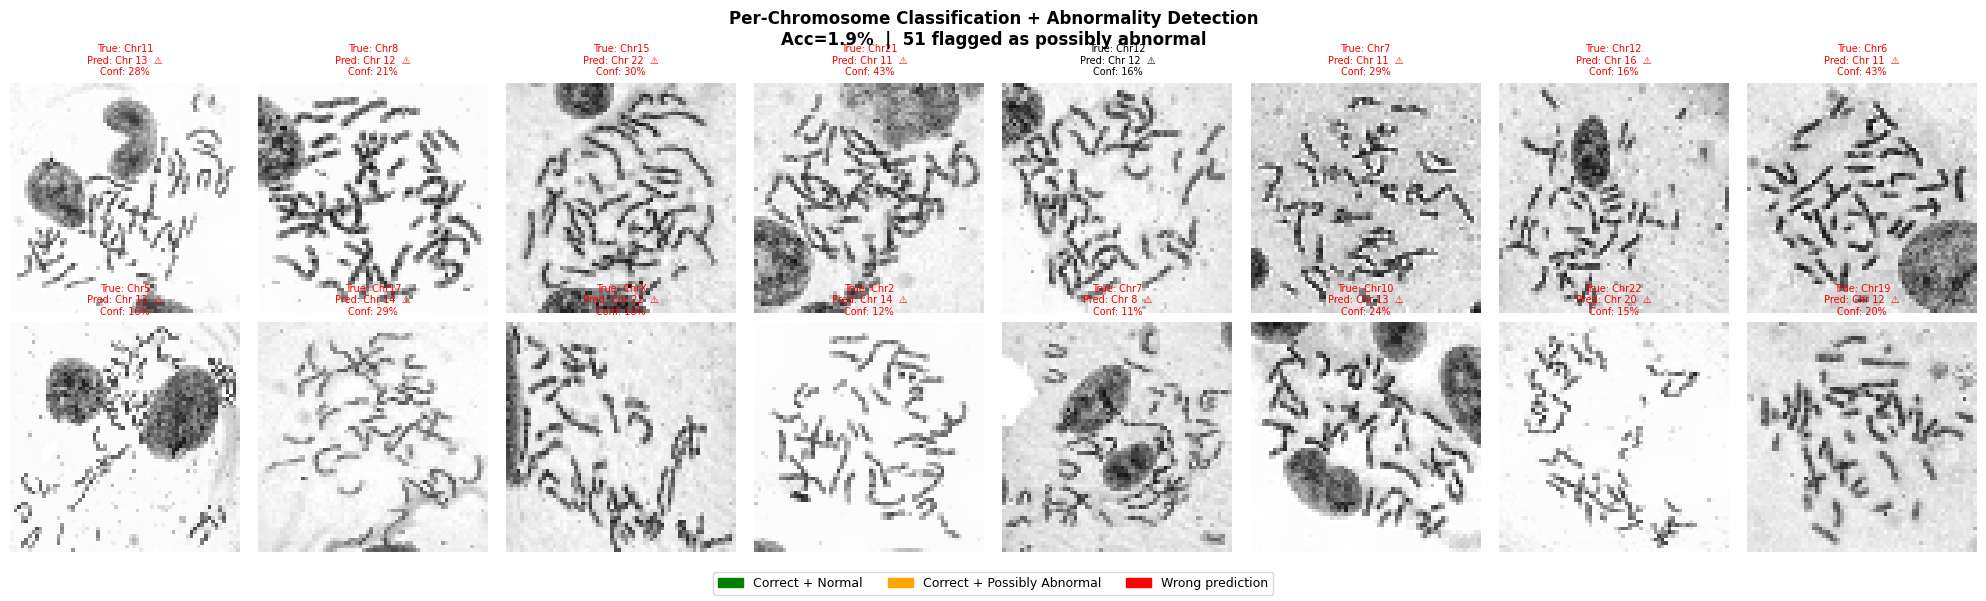

✅ Prediction visualization saved


In [32]:
def visualize_predictions(n_samples=16):
    """
    Show n_samples test images with:
    - True class label
    - Predicted class label
    - Confidence score
    - Normal / Abnormal flag
    Green border = correct prediction
    Red border   = wrong prediction
    Orange border = correct but flagged as abnormal
    """
    indices = random.sample(range(len(X_test)), min(n_samples, len(X_test)))
    ncols   = 8
    nrows   = (len(indices) + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*2.5, nrows*3))
    axes      = axes.flatten()

    for ax_i, idx in enumerate(indices):
        ax   = axes[ax_i]
        pred = predictions[idx]
        img  = X_test[idx]

        ax.imshow(img)
        ax.axis('off')

        # Border color
        if not pred['correct']:
            color = 'red'
        elif pred['is_abnormal']:
            color = 'orange'
        else:
            color = 'green'

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color(color)
            spine.set_linewidth(3)

        true_name = CLASS_NAMES[int(y_true[idx])]
        pred_name = pred['chromosome_name']
        conf_pct  = pred['confidence'] * 100
        abn_icon  = '⚠' if pred['is_abnormal'] else ''

        title = (
            f'True: Chr{true_name}\n'
            f'Pred: {pred_name}  {abn_icon}\n'
            f'Conf: {conf_pct:.0f}%'
        )
        ax.set_title(title, fontsize=7,
                     color='black' if pred['correct'] else 'red')

    for ax in axes[len(indices):]:
        ax.axis('off')

    # Legend
    legend = [
        mpatches.Patch(color='green',  label='Correct + Normal'),
        mpatches.Patch(color='orange', label='Correct + Possibly Abnormal'),
        mpatches.Patch(color='red',    label='Wrong prediction'),
    ]
    fig.legend(handles=legend, loc='lower center', ncol=3, fontsize=9)

    plt.suptitle(
        f'Per-Chromosome Classification + Abnormality Detection\n'
        f'Acc={acc:.1f}%  |  {n_abnormal} flagged as possibly abnormal',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig('/content/outputs/sample_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()


visualize_predictions(n_samples=16)
print('✅ Prediction visualization saved')

## Cell 20 — Save Results & Summary 

In [38]:
# ── Save per-chromosome prediction results to CSV ────────────────────────
results_df = pd.DataFrame([{
    'image_index'     : i,
    'true_class'      : CLASS_NAMES[int(y_true[i])],
    'predicted_class' : p['chromosome_name'],
    'confidence_pct'  : round(p['confidence'] * 100, 2),
    'correct'         : p['correct'],
    'is_abnormal'     : p['is_abnormal'],
    'abnormality_type': p['abnormality_type'],
    'denver_group'    : p['denver_group'],
} for i, p in enumerate(predictions)])

results_df.to_csv('/content/outputs/per_chromosome_results.csv', index=False)
print('Saved: per_chromosome_results.csv')
print(results_df.head(10).to_string())

# ── Final summary printout ────────────────────────────────────────────────
print('\n' + '='*60)
print('  SMALL-SCALE PROOF OF CONCEPT — RESULTS SUMMARY')
print('='*60)
print(f'  Dataset size     : {IMAGES_PER_CLASS} images/class × 24 classes')
print(f'  Image size       : {IMG_SIZE}×{IMG_SIZE}')
print(f'  Test accuracy    : {acc:.2f}%')
print(f'  Macro F1         : {f1:.4f}')
print(f'  Precision        : {precision:.4f}')
print(f'  Recall           : {recall:.4f}')
print(f'  Chromosomes analyzed   : {len(predictions)}')
print(f'  Flagged abnormal       : {n_abnormal} ({n_abnormal/len(predictions)*100:.1f}%)')
print('='*60)
print('\n  TO SCALE UP:')
print('  Cell 3: Set IMAGES_PER_CLASS = 130')
print('  Cell 3: Set IMG_SIZE = 224')
print('  Cell 10: Set REPEAT = 23  (full CDA from paper)')
print('  Cell 12: Set EPOCHS_P1 = 15')
print('  Cell 13: Set EPOCHS_P2 = 50')
print('  Expected full-scale accuracy: 90-96%')
print('='*60)

# Copy outputs to Drive
try:
    import shutil
    drive_out = '/content/drive/MyDrive/CIRNet_Output'
    os.makedirs(drive_out, exist_ok=True)
    for f in os.listdir('/content/outputs'):
        shutil.copy(f'/content/outputs/{f}', f'{drive_out}/{f}')
    print(f'\n✅ All outputs saved to Drive: {drive_out}')
except:
    print('\n(Drive copy skipped — outputs available at /content/outputs/)')

Saved: per_chromosome_results.csv
   image_index true_class predicted_class  confidence_pct  correct  is_abnormal                    abnormality_type denver_group
0            0         11          Chr 13           28.13    False         True  Low Confidence — Possibly Abnormal            D
1            1          X          Chr 14           16.17    False         True  Low Confidence — Possibly Abnormal            D
2            2          4          Chr 22           52.48    False         True  Low Confidence — Possibly Abnormal            G
3            3          5           Chr 1           12.55    False         True  Low Confidence — Possibly Abnormal            A
4            4         16          Chr 14           17.11    False         True  Low Confidence — Possibly Abnormal            D
5            5         13          Chr 22           11.26    False         True  Low Confidence — Possibly Abnormal            G
6            6         18          Chr 12           14.41    Fa